In [11]:
# ==============================================================
# CELL 1 — CONFIG
# ==============================================================
import numpy as np
import laspy
import pandas as pd
from pathlib import Path
from pyproj import Transformer
from scipy.spatial.transform import Rotation, Slerp
import sys
sys.path.insert(0, "/home/b085164/PDM_Romain_Defferrard/ESO-PDM")

# Nuage Combined — source des correspondances LiMatch
COMBINED_DIR = Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/APX/georef_COMBINED/merged/ALL")

# Nuage Outage — à évaluer
OUTAGE_DIR = Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/APX/merged/ALL")

OUT_BASE = Path("/media/b085164/Elements/CALIB_26_02_25/georef_ALL_traj_outage_3/APX/relative_error_eval")
OUT_BASE.mkdir(parents=True, exist_ok=True)

LIMATCH_CFG   = "/home/b085164/PDM_Romain_Defferrard/ESO-PDM/Patcher/submodules/limatch/configs/MLS.yml"

# Paires : (merged_id_a, (t_start_a, t_end_a), merged_id_b, (t_start_b, t_end_b))
# Δt dans l'outage indiqué 
# Outage ECCR DONE
# PAIRS = [
#     (2000, (315700, 315710), 3000, (315745, 315756)),  # Δt ~60s / ~100s in outage
#     (1000, (315644, 315650), 4000, (315799, 315809)),  # Δt ~0s  / ... s in outage
#     (4000, (315815, 315830), 8000, (316051, 316065)),
#     (5000, (315848, 315861), 6000, (315915, 315925)),
#     (6000, (315926, 315940), 8000, (316028, 316038)),
#     (7000, (315972, 315979), 8000, (316024, 316032)),
# ]

# Outage 3 CALIB DONE
PAIRS = [
    (1000, (306310, 306315), 5000, (306622, 306627)),  
    (1000, (306335, 306340), 5000, (306596, 306601)),  
    (2000, (306383, 306395), 5000, (306574, 306581)),
]

# Outage 2 CALIB
# PAIRS = [
#     (9000, (305818, 305828), 10000, (305849, 305858)),  
#     (11000, (305878, 305885), 15000, (305929, 305933)),  
#     (18000, (305980, 305985), 19000, (306067, 306072)),
#     (2000, (305725, 305733), 9000, (305797, 305804)),  
# ]


# Outage 1 CALIB
# PAIRS = [
#     (2000, (305365, 305371), 3000, (305439, 305447)),
#     (2000, (305330, 305340), 3000, (305473, 305485)),
#     (1000, (305264, 305272), 3000, (305547, 305556)),
# ]

print(f"{len(PAIRS)} paires configurées")
for i, (sa, ta, sb, tb) in enumerate(PAIRS):
    dt = tb[0] - ta[1]
    print(f"  Paire {i+1}: merged_{sa} [{ta[0]}-{ta[1]}] ↔ merged_{sb} [{tb[0]}-{tb[1]}]  Δt≈{dt:.0f}s")

3 paires configurées
  Paire 1: merged_1000 [306310-306315] ↔ merged_5000 [306622-306627]  Δt≈307s
  Paire 2: merged_1000 [306335-306340] ↔ merged_5000 [306596-306601]  Δt≈256s
  Paire 3: merged_2000 [306383-306395] ↔ merged_5000 [306574-306581]  Δt≈179s


In [12]:
# ==============================================================
# CELL 2 — CROP depuis le nuage Combined
# ==============================================================
def crop_las_by_time(las_path, t0, t1, out_path):
    if out_path.exists():
        print(f"  [SKIP] {out_path.name} déjà existant")
        return out_path
    las  = laspy.read(las_path)
    t    = np.asarray(las.gps_time)
    mask = (t >= t0) & (t <= t1)
    n_kept = int(mask.sum())
    print(f"  {las_path.name}: {n_kept:,} pts dans [{t0}, {t1}]", end=" ")
    if n_kept == 0:
        print(f"!! vide (t_min={t.min():.1f} t_max={t.max():.1f})")
        return None
    las[mask].write(out_path)
    print(f"→ {out_path.name}")
    return out_path

crop_paths = []

for i, (sid_a, t_crop_a, sid_b, t_crop_b) in enumerate(PAIRS):
    out_dir = OUT_BASE / f"pair_{i+1}_{sid_a}_{sid_b}"
    out_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n{'='*55}\nPaire {i+1} — merged_{sid_a} / merged_{sid_b}\n{'='*55}")

    path_a = crop_las_by_time(
        COMBINED_DIR / f"merged_{sid_a}_VUX_PUCK.las",
        *t_crop_a,
        out_dir / f"scan_{sid_a}_crop.las"
    )
    path_b = crop_las_by_time(
        COMBINED_DIR / f"merged_{sid_b}_VUX_PUCK.las",
        *t_crop_b,
        out_dir / f"scan_{sid_b}_crop.las"
    )
    crop_paths.append((i, out_dir, path_a, path_b))
# Reconstruit crop_paths sans recropper
# Reconstruit crop_paths et limatch_results depuis le disque
# crop_paths      = []
# limatch_results = []

# for i, (sid_a, t_crop_a, sid_b, t_crop_b) in enumerate(PAIRS):
#     out_dir = OUT_BASE / f"pair_{i+1}_{sid_a}_{sid_b}"
#     path_a  = out_dir / f"scan_{sid_a}_crop.las"
#     path_b  = out_dir / f"scan_{sid_b}_crop.las"

#     crop_paths.append((
#         i, out_dir,
#         path_a if path_a.exists() else None,
#         path_b if path_b.exists() else None,
#     ))

#     lm_dir  = out_dir / "limatch"
#     existing = list(lm_dir.rglob("corres_*.txt"))
#     if existing:
#         limatch_results.append((i, out_dir, existing[0]))
#         print(f"Paire {i+1} — OK  [{existing[0].name}]")
#     else:
#         print(f"Paire {i+1} — !! corres_*.txt manquant dans {lm_dir}")

# print(f"\n{len(limatch_results)}/{len(PAIRS)} paires avec correspondances.")
print("\nCrop terminé.")


Paire 1 — merged_1000 / merged_5000
  [SKIP] scan_1000_crop.las déjà existant
  [SKIP] scan_5000_crop.las déjà existant

Paire 2 — merged_1000 / merged_5000
  [SKIP] scan_1000_crop.las déjà existant
  [SKIP] scan_5000_crop.las déjà existant

Paire 3 — merged_2000 / merged_5000
  [SKIP] scan_2000_crop.las déjà existant
  [SKIP] scan_5000_crop.las déjà existant

Crop terminé.


In [13]:
# ==============================================================
# CELL 3 — LANCER LIMATCH sur toutes les paires
# ==============================================================
from navtools_PDM.pipeline import run_limatch_api, get_repo_root

repo_root       = get_repo_root()
limatch_results = []

for i, out_dir, out_a, out_b in crop_paths:
    if out_a is None or out_b is None:
        print(f"Paire {i+1} — crop vide, skip")
        continue

    lm_dir = out_dir / "limatch"

    # Skip si déjà fait
    existing = list(lm_dir.rglob("corres_*.txt"))
    if existing:
        print(f"Paire {i+1} — [SKIP] corres déjà existant : {existing[0].name}")
        limatch_results.append((i, out_dir, existing[0]))
        continue

    print(f"\n{'='*55}\nLiMatch paire {i+1}\n{'='*55}")
    run_limatch_api(
        repo_root=repo_root,
        limatch_cfg_path=LIMATCH_CFG,
        cloud1=out_a,
        cloud2=out_b,
        out_dir=lm_dir,
    )

    corres_files = list(lm_dir.rglob("corres_*.txt"))
    if corres_files:
        limatch_results.append((i, out_dir, corres_files[0]))
        print(f"  → {corres_files[0].name}")
    else:
        print(f"  !! Pas de corres_*.txt")

print(f"\n{len(limatch_results)}/{len(PAIRS)} paires avec correspondances.")

Paire 1 — [SKIP] corres déjà existant : corres_scan_1000_crop_scan_5000_crop.txt
Paire 2 — [SKIP] corres déjà existant : corres_scan_1000_crop_scan_5000_crop.txt
Paire 3 — [SKIP] corres déjà existant : corres_scan_2000_crop_scan_5000_crop.txt

3/3 paires avec correspondances.


In [14]:
# ==============================================================
# CELL 5 — COMPUTE ERREUR RELATIVE (Combined vs Outage)
# ==============================================================
CORRES_COLS = ["time_a","x_a","y_a","z_a",
               "time_b","x_b","y_b","z_b",
               "d_xyz","icp_x","icp_y","icp_z"]

def load_corres(path):
    df = pd.read_csv(path, header=None, names=CORRES_COLS,
                     sep=r",\s*", engine="python", skiprows=1)
    return df.apply(pd.to_numeric, errors="coerce").dropna()

def get_xyz_for_times(las_path, times_list, tol=1e-9):
    """
    Charge tout le LAS, trie par temps, searchsorted pour chaque timestamp.
    """
    times_arr = np.array(list(times_list), dtype=np.float64)

    las = laspy.read(las_path)
    t   = np.asarray(las.gps_time, dtype=np.float64)
    x   = np.asarray(las.x,        dtype=np.float64)
    y   = np.asarray(las.y,        dtype=np.float64)
    z   = np.asarray(las.z,        dtype=np.float64)

    order = np.argsort(t)
    t = t[order]; x = x[order]; y = y[order]; z = z[order]

    result = {}
    n_ambig = 0
    for ti in times_arr:
        idx = np.searchsorted(t, ti)
        candidates = []
        for j in [idx-1, idx, idx+1]:
            if 0 <= j < len(t) and abs(t[j] - ti) < tol:
                candidates.append(j)
        if len(candidates) == 1:
            j = candidates[0]
            result[ti] = np.array([x[j], y[j], z[j]])
        elif len(candidates) > 1:
            n_ambig += 1

    n_miss = len(times_arr) - len(result) - n_ambig
    print(f"    {len(result)}/{len(times_arr)} trouvés  "
          f"|  {n_ambig} ambigus  |  {n_miss} absents")
    return result

# --- Évaluation ---
all_rows = []

for i, out_dir, corres_path in limatch_results:
    sid_a, t_crop_a, sid_b, t_crop_b = \
        PAIRS[i][0], PAIRS[i][1], PAIRS[i][2], PAIRS[i][3]
    dt_outage = t_crop_b[0] - t_crop_a[1]

    print(f"\nPaire {i+1} — merged_{sid_a} / merged_{sid_b}  Δt≈{dt_outage:.0f}s")

    # 1. Charge le fichier corres
    df_corres = load_corres(corres_path)
    print(f"  {len(df_corres)} correspondances")

    # 2. Timestamps nécessaires
    times_a = set(df_corres["time_a"].values)
    times_b = set(df_corres["time_b"].values)

    # 3. Cherche dans merged_a
    print(f"  Fichier A — merged_{sid_a}:")
    xyz_a = get_xyz_for_times(
        OUTAGE_DIR / f"merged_{sid_a}_VUX_PUCK.las", times_a)

    # 4. Cherche dans merged_b
    print(f"  Fichier B — merged_{sid_b}:")
    xyz_b = get_xyz_for_times(
        OUTAGE_DIR / f"merged_{sid_b}_VUX_PUCK.las", times_b)

    # 5. Calcule d_outage pour chaque paire
    n_found = n_miss = 0
    for _, row in df_corres.iterrows():
        ta = row["time_a"]
        tb = row["time_b"]

        P_a = xyz_a.get(ta, None)
        P_b = xyz_b.get(tb, None)

        if P_a is None or P_b is None:
            n_miss += 1
            continue

        n_found += 1
        all_rows.append({
            "pair":       i + 1,
            "dt_outage":  dt_outage,
            "time_a":     ta,
            "time_b":     tb,
            "d_combined": float(row["d_xyz"]),
            "d_outage":   float(np.linalg.norm(P_a - P_b)),
        })

    print(f"  → {n_found} évaluées  |  {n_miss} non trouvées")

df_all = pd.DataFrame(all_rows)

# Stats
print("\n--- Summary ---")
print(f"{'':12} {'N':>6} {'Q50 [cm]':>10} {'Q95 [cm]':>10} {'RMSE [cm]':>10}")
print("-"*50)
for label, col in [("Combined", "d_combined"), ("Outage", "d_outage")]:
    d = df_all[col].dropna().values * 100
    print(f"  {label:<10} {len(d):>6} {np.median(d):>10.2f} "
          f"{np.percentile(d,95):>10.2f} {np.sqrt(np.mean(d**2)):>10.2f}")


Paire 1 — merged_1000 / merged_5000  Δt≈307s
  4448 correspondances
  Fichier A — merged_1000:
    3097/4446 trouvés  |  1349 ambigus  |  0 absents
  Fichier B — merged_5000:
    3203/4444 trouvés  |  1241 ambigus  |  0 absents
  → 2466 évaluées  |  1982 non trouvées

Paire 2 — merged_1000 / merged_5000  Δt≈256s
  2126 correspondances
  Fichier A — merged_1000:
    1513/2126 trouvés  |  613 ambigus  |  0 absents
  Fichier B — merged_5000:
    1448/2123 trouvés  |  674 ambigus  |  1 absents
  → 1198 évaluées  |  928 non trouvées

Paire 3 — merged_2000 / merged_5000  Δt≈179s
  7200 correspondances
  Fichier A — merged_2000:
    5483/7196 trouvés  |  1713 ambigus  |  0 absents
  Fichier B — merged_5000:
    5493/7196 trouvés  |  1703 ambigus  |  0 absents
  → 4840 évaluées  |  2360 non trouvées

--- Summary ---
                  N   Q50 [cm]   Q95 [cm]  RMSE [cm]
--------------------------------------------------
  Combined     8504       1.10      24.00       9.91
  Outage       8504   

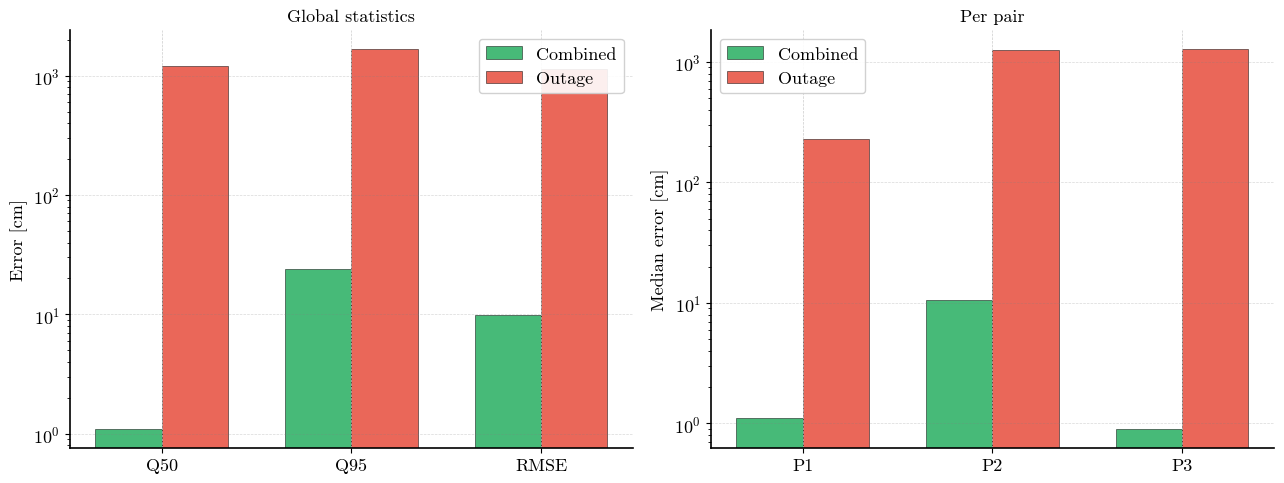


--- Relative error summary ---
Scenario          N   Q50 [cm]   Q95 [cm]  RMSE [cm]
--------------------------------------------------
  Combined     8504       1.10      24.00       9.91
  Outage       8504    1199.37    1678.91    1134.59


In [15]:
import matplotlib.pyplot as plt

COLORS = {"Combined": "#27ae60", "Outage": "#e74c3c"}
FS = 13

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- AX1 : stats globales ---
x2 = np.arange(3)
for j, (label, col) in enumerate([("Combined", "d_combined"),
                                   ("Outage",   "d_outage")]):
    d    = df_all[col].dropna().values * 100
    vals = [np.median(d), np.percentile(d, 95), np.sqrt(np.mean(d**2))]
    ax1.bar(x2 + j*0.35, vals, width=0.35,
            color=COLORS[label], alpha=0.85, label=label,
            edgecolor="k", lw=0.4)

ax1.set_xticks(x2 + 0.175)
ax1.set_xticklabels(["Q50", "Q95", "RMSE"], fontsize=FS)
ax1.set_ylabel("Error [cm]", fontsize=FS)
ax1.set_title("Global statistics", fontsize=FS)
ax1.set_yscale("log")
ax1.tick_params(axis="both", labelsize=FS)
ax1.legend(fontsize=FS)
ax1.grid(axis="y", color="grey", ls="--", alpha=0.3)
ax1.spines[["top","right"]].set_visible(False)

# --- AX2 : médiane par paire ---
pair_ids = sorted(df_all["pair"].unique())
x = np.arange(len(pair_ids))
width = 0.35

for j, (label, col) in enumerate([("Combined", "d_combined"),
                                   ("Outage",   "d_outage")]):
    medians = [df_all[df_all["pair"]==p][col].median()*100 for p in pair_ids]
    ax2.bar(x + j*width, medians, width=width,
            color=COLORS[label], alpha=0.85, label=label,
            edgecolor="k", lw=0.4)

ax2.set_xticks(x + width/2)
ax2.set_xticklabels([f"P{p}" for p in pair_ids], fontsize=FS)
ax2.set_ylabel("Median error [cm]", fontsize=FS)
ax2.set_title("Per pair", fontsize=FS)
ax2.set_yscale("log")
ax2.tick_params(axis="both", labelsize=FS)
ax2.legend(fontsize=FS)
ax2.grid(axis="y", color="grey", ls="--", alpha=0.3)
ax2.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(str(OUT_BASE / "relative_error_global_AIRINS_out1.png"), dpi=400, bbox_inches="tight")
plt.show()

print("\n--- Relative error summary ---")
print(f"{'Scenario':<12} {'N':>6} {'Q50 [cm]':>10} {'Q95 [cm]':>10} {'RMSE [cm]':>10}")
print("-"*50)
for label, col in [("Combined", "d_combined"), ("Outage", "d_outage")]:
    d = df_all[col].dropna().values * 100
    print(f"  {label:<10} {len(d):>6} {np.median(d):>10.2f} "
          f"{np.percentile(d,95):>10.2f} {np.sqrt(np.mean(d**2)):>10.2f}")

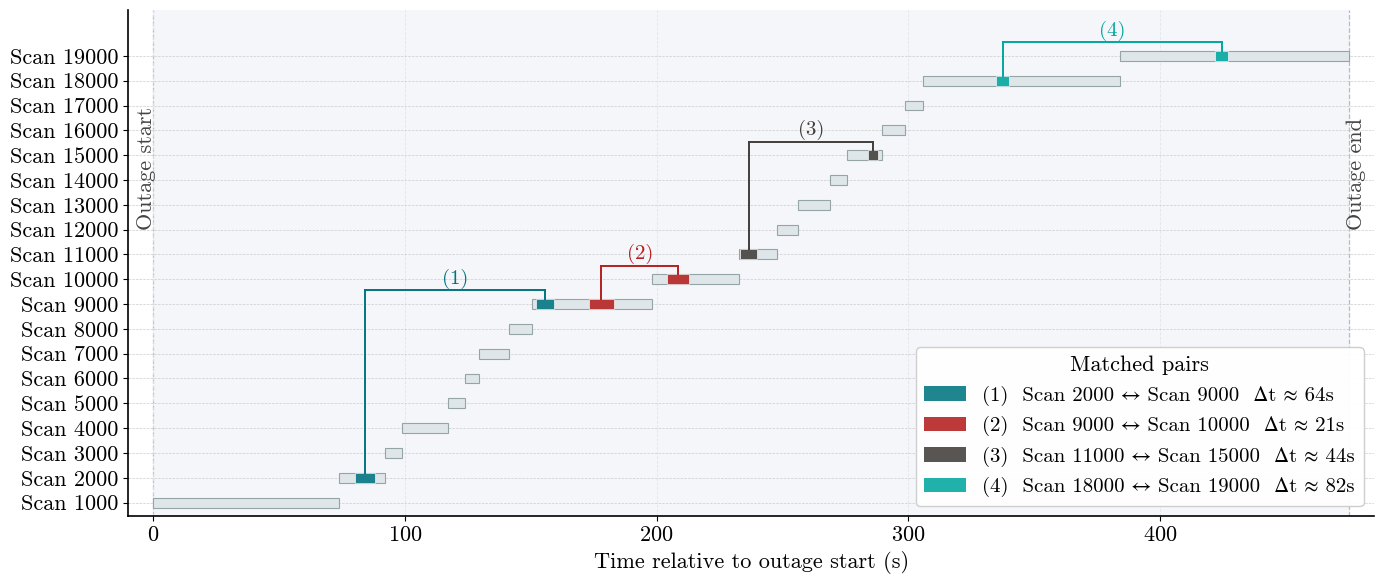

Done


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

FS = 16

fig, ax_cross = plt.subplots(figsize=(14, 6))

T_OUTAGE_START = 305645
T_OUTAGE_END   = 306120
T0 = T_OUTAGE_START
def tr(t): return t - T0

SCANLINES = {
     1000: (305645.0, 305718.8),
     2000: (305718.8, 305737.2),
     3000: (305737.2, 305743.6),
     4000: (305743.6, 305762.1),
     5000: (305762.1, 305768.9),
     6000: (305768.9, 305774.5),
     7000: (305774.5, 305786.4),
     8000: (305786.4, 305795.6),
     9000: (305795.6, 305843.0),
    10000: (305843.0, 305877.8),
    11000: (305877.8, 305892.7),
    12000: (305892.7, 305901.0),
    13000: (305901.0, 305913.7),
    14000: (305913.7, 305920.5),
    15000: (305920.5, 305934.5),
    16000: (305934.5, 305943.7),
    17000: (305943.7, 305950.9),
    18000: (305950.9, 306029.2),
    19000: (306029.2, 306120.0),
}

PAIRS_PLOT = [
    ( 2000, 305725, 305733,  9000, 305797, 305804),
    ( 9000, 305818, 305828, 10000, 305849, 305858),
    (11000, 305878, 305885, 15000, 305929, 305933),
    (18000, 305980, 305985, 19000, 306067, 306072),
]

COLORS_PLOT = [
    "#007480",  # (1) Canard
    "#B51F1F",  # (2) Groseille
    "#413D3A",  # (3) Ardoise
    "#00A79F",  # (4) Léman
]
BRIDGE_OFFSETS = [0.55, 0.55, 0.55, 0.55]

SCAN_IDS = sorted(SCANLINES.keys())
y_map    = {sid: i for i, sid in enumerate(SCAN_IDS)}
N        = len(SCAN_IDS)

def intervals_overlap(a0, a1, b0, b1): return a0 < b1 and b0 < a1

scan_pair_windows = defaultdict(list)
for idx, pair in enumerate(PAIRS_PLOT):
    sA, tsA, teA, sB, tsB, teB = pair
    scan_pair_windows[sA].append((idx, tsA, teA, "A"))
    scan_pair_windows[sB].append((idx, tsB, teB, "B"))

segment_slot = {}
for sid, entries in scan_pair_windows.items():
    used = [False]*len(entries); groups = []
    for i in range(len(entries)):
        if used[i]: continue
        group = [i]; used[i] = True
        for j in range(i+1, len(entries)):
            if used[j]: continue
            for k in group:
                _, t0_, t1_, _ = entries[k]; _, t0j, t1j, _ = entries[j]
                if intervals_overlap(t0_, t1_, t0j, t1j):
                    group.append(j); used[j] = True; break
        groups.append(group)
    for group in groups:
        for slot, g_idx in enumerate(group):
            pidx, ts, te, role = entries[g_idx]
            segment_slot[(pidx, role)] = (slot, len(group))

def draw_segment(ax, y, ts, te, color, slot, n_slots):
    H_FULL = 0.4; h = H_FULL/n_slots
    y0 = y + H_FULL/2 - h/2 - slot*h
    ax.barh(y0, tr(te)-tr(ts), left=tr(ts), height=h,
            color=color, alpha=0.88, edgecolor="white", lw=0.5, zorder=3)

ax_cross.axvspan(tr(T_OUTAGE_START), tr(T_OUTAGE_END), color="#f5f6fa", zorder=0)
for xv in [tr(T_OUTAGE_START), tr(T_OUTAGE_END)]:
    ax_cross.axvline(xv, color="#b2bec3", lw=0.9, ls="--", zorder=1)

for sid, (ts, te) in SCANLINES.items():
    ax_cross.barh(y_map[sid], tr(te)-tr(ts), left=tr(ts), height=0.4,
                  color="#dfe6e9", edgecolor="#95a5a6", lw=0.8, zorder=2)

for idx, (pair, color) in enumerate(zip(PAIRS_PLOT, COLORS_PLOT)):
    sA, tsA, teA, sB, tsB, teB = pair
    slot_A, n_A = segment_slot.get((idx,"A"),(0,1))
    slot_B, n_B = segment_slot.get((idx,"B"),(0,1))
    draw_segment(ax_cross, y_map[sA], tsA, teA, color, slot_A, n_A)
    draw_segment(ax_cross, y_map[sB], tsB, teB, color, slot_B, n_B)
    yA = y_map[sA]; yB = y_map[sB]
    xA = tr((tsA+teA)/2); xB = tr((tsB+teB)/2)
    y_bridge = max(yA,yB) + BRIDGE_OFFSETS[idx]
    ax_cross.plot([xA,xA],[yA+0.2,y_bridge], color=color, lw=1.4, zorder=4)
    ax_cross.plot([xB,xB],[yB+0.2,y_bridge], color=color, lw=1.4, zorder=4)
    ax_cross.plot([xA,xB],[y_bridge,y_bridge], color=color, lw=1.4, zorder=4)
    ax_cross.text((xA+xB)/2, y_bridge+0.07, f"({idx+1})",
                  ha="center", va="bottom", fontsize=FS-1,
                  color=color, fontweight="bold")

ax_cross.set_yticks(list(y_map.values()))
ax_cross.set_yticklabels([f"Scan {sid}" for sid in SCAN_IDS], fontsize=FS)
ax_cross.set_xlabel("Time relative to outage start (s)", fontsize=FS)
ax_cross.tick_params(axis="both", labelsize=FS)
ax_cross.set_xlim(tr(305635), tr(306130))
ax_cross.set_ylim(-0.55, N + 0.85)
ax_cross.grid(axis="x", color="#dfe6e9", lw=0.6, zorder=0)
ax_cross.spines[["top","right"]].set_visible(False)

ax_cross.text(tr(T_OUTAGE_START)-3, N-8, "Outage start",
              fontsize=FS, color="#444444",
              va="bottom", ha="center", fontstyle="italic", rotation=90)
ax_cross.text(tr(T_OUTAGE_END)+3, N-8, "Outage end",
              fontsize=FS, color="#444444",
              va="bottom", ha="center", fontstyle="italic", rotation=90)

legend_handles = [
    mpatches.Patch(facecolor=c, alpha=0.88,
                   label=f"({i+1})  Scan {p[0]} ↔ Scan {p[3]}  "
                         f"Δt ≈ {p[4]-p[2]:.0f}s")
    for i, (p, c) in enumerate(zip(PAIRS_PLOT, COLORS_PLOT))
]
ax_cross.legend(handles=legend_handles, fontsize=FS-1, ncol=1,
                loc="lower right", framealpha=0.95,
                title="Matched pairs", title_fontsize=FS)

plt.tight_layout()
plt.savefig("/home/b085164/PDM_Romain_Defferrard/images/crossing_out2_relative_eval.png",
            bbox_inches="tight", dpi=400)
plt.show()
print("Done")

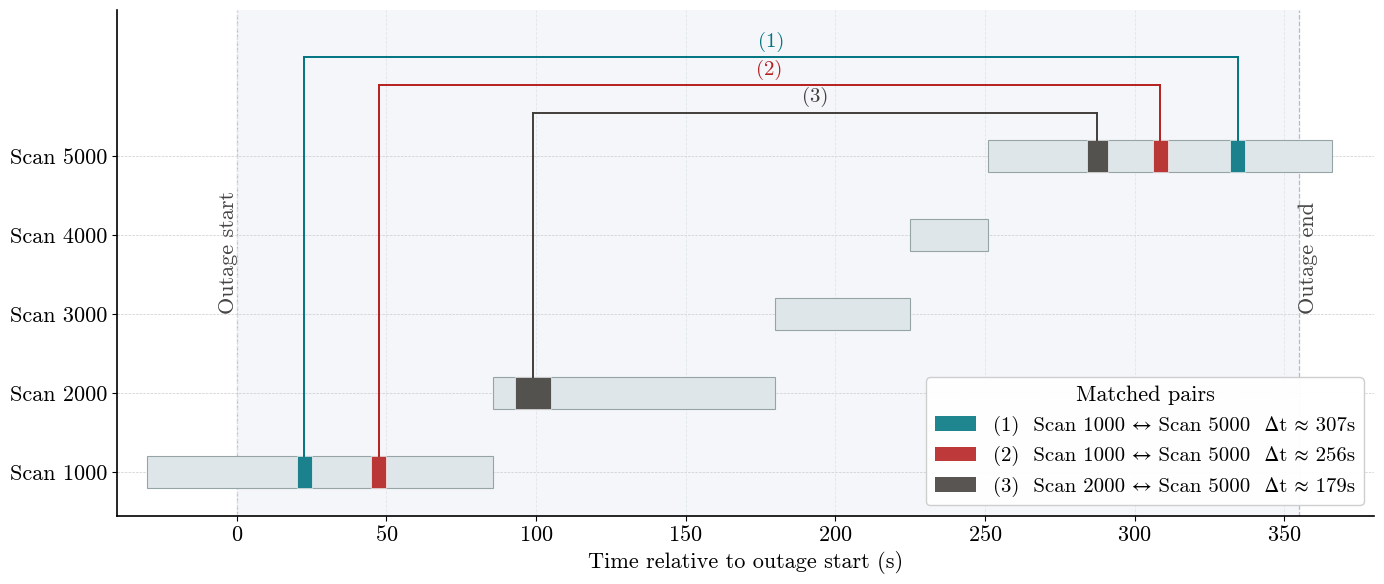

Done


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

FS = 16

fig, ax_cross = plt.subplots(figsize=(14, 6))

T_OUTAGE_START = 306290
T_OUTAGE_END   = 306645
T0 = T_OUTAGE_START
def tr(t): return t - T0

SCANLINES = {
    1000: (306260.0, 306375.6),
    2000: (306375.6, 306470.0),
    3000: (306470.0, 306514.9),
    4000: (306514.9, 306541.0),
    5000: (306541.0, 306655.8),
}

PAIRS_PLOT = [
    (1000, 306310, 306315, 5000, 306622, 306627),
    (1000, 306335, 306340, 5000, 306596, 306601),
    (2000, 306383, 306395, 5000, 306574, 306581),
]

COLORS_PLOT = [
    "#007480",
    "#B51F1F",
    "#413D3A",
]
BRIDGE_OFFSETS = [1.25, 0.90, 0.55]

SCAN_IDS = sorted(SCANLINES.keys())
y_map    = {sid: i for i, sid in enumerate(SCAN_IDS)}
N        = len(SCAN_IDS)

def intervals_overlap(a0, a1, b0, b1): return a0 < b1 and b0 < a1

scan_pair_windows = defaultdict(list)
for idx, pair in enumerate(PAIRS_PLOT):
    sA, tsA, teA, sB, tsB, teB = pair
    scan_pair_windows[sA].append((idx, tsA, teA, "A"))
    scan_pair_windows[sB].append((idx, tsB, teB, "B"))

segment_slot = {}
for sid, entries in scan_pair_windows.items():
    used = [False]*len(entries); groups = []
    for i in range(len(entries)):
        if used[i]: continue
        group = [i]; used[i] = True
        for j in range(i+1, len(entries)):
            if used[j]: continue
            for k in group:
                _, t0_, t1_, _ = entries[k]; _, t0j, t1j, _ = entries[j]
                if intervals_overlap(t0_, t1_, t0j, t1j):
                    group.append(j); used[j] = True; break
        groups.append(group)
    for group in groups:
        for slot, g_idx in enumerate(group):
            pidx, ts, te, role = entries[g_idx]
            segment_slot[(pidx, role)] = (slot, len(group))

def draw_segment(ax, y, ts, te, color, slot, n_slots):
    H_FULL = 0.4; h = H_FULL/n_slots
    y0 = y + H_FULL/2 - h/2 - slot*h
    ax.barh(y0, tr(te)-tr(ts), left=tr(ts), height=h,
            color=color, alpha=0.88, edgecolor="white", lw=0.5, zorder=3)

ax_cross.axvspan(tr(T_OUTAGE_START), tr(T_OUTAGE_END), color="#f5f6fa", zorder=0)
for xv in [tr(T_OUTAGE_START), tr(T_OUTAGE_END)]:
    ax_cross.axvline(xv, color="#b2bec3", lw=0.9, ls="--", zorder=1)

for sid, (ts, te) in SCANLINES.items():
    ax_cross.barh(y_map[sid], tr(te)-tr(ts), left=tr(ts), height=0.4,
                  color="#dfe6e9", edgecolor="#95a5a6", lw=0.8, zorder=2)

for idx, (pair, color) in enumerate(zip(PAIRS_PLOT, COLORS_PLOT)):
    sA, tsA, teA, sB, tsB, teB = pair
    slot_A, n_A = segment_slot.get((idx,"A"),(0,1))
    slot_B, n_B = segment_slot.get((idx,"B"),(0,1))
    draw_segment(ax_cross, y_map[sA], tsA, teA, color, slot_A, n_A)
    draw_segment(ax_cross, y_map[sB], tsB, teB, color, slot_B, n_B)
    yA = y_map[sA]; yB = y_map[sB]
    xA = tr((tsA+teA)/2); xB = tr((tsB+teB)/2)
    y_bridge = max(yA,yB) + BRIDGE_OFFSETS[idx]
    ax_cross.plot([xA,xA],[yA+0.2,y_bridge], color=color, lw=1.4, zorder=4)
    ax_cross.plot([xB,xB],[yB+0.2,y_bridge], color=color, lw=1.4, zorder=4)
    ax_cross.plot([xA,xB],[y_bridge,y_bridge], color=color, lw=1.4, zorder=4)
    ax_cross.text((xA+xB)/2, y_bridge+0.07, f"({idx+1})",
                  ha="center", va="bottom", fontsize=FS-1,
                  color=color, fontweight="bold")

ax_cross.set_yticks(list(y_map.values()))
ax_cross.set_yticklabels([f"Scan {sid}" for sid in SCAN_IDS], fontsize=FS)
ax_cross.set_xlabel("Time relative to outage start (s)", fontsize=FS)
ax_cross.tick_params(axis="both", labelsize=FS)
ax_cross.set_xlim(tr(306250), tr(306670))
ax_cross.set_ylim(-0.55, N + 0.85)
ax_cross.grid(axis="x", color="#dfe6e9", lw=0.6, zorder=0)
ax_cross.spines[["top","right"]].set_visible(False)

ax_cross.text(tr(T_OUTAGE_START)-3, N-3, "Outage start",
              fontsize=FS, color="#444444",
              va="bottom", ha="center", fontstyle="italic", rotation=90)
ax_cross.text(tr(T_OUTAGE_END)+3, N-3, "Outage end",
              fontsize=FS, color="#444444",
              va="bottom", ha="center", fontstyle="italic", rotation=90)

legend_handles = [
    mpatches.Patch(facecolor=c, alpha=0.88,
                   label=f"({i+1})  Scan {p[0]} ↔ Scan {p[3]}  "
                         f"Δt ≈ {p[4]-p[2]:.0f}s")
    for i, (p, c) in enumerate(zip(PAIRS_PLOT, COLORS_PLOT))
]
ax_cross.legend(handles=legend_handles, fontsize=FS-1, ncol=1,
                loc="lower right", framealpha=0.95,
                title="Matched pairs", title_fontsize=FS)

plt.tight_layout()
plt.savefig("/home/b085164/PDM_Romain_Defferrard/images/crossing_out3_relative_eval.png",
            bbox_inches="tight", dpi=400)
plt.show()
print("Done")

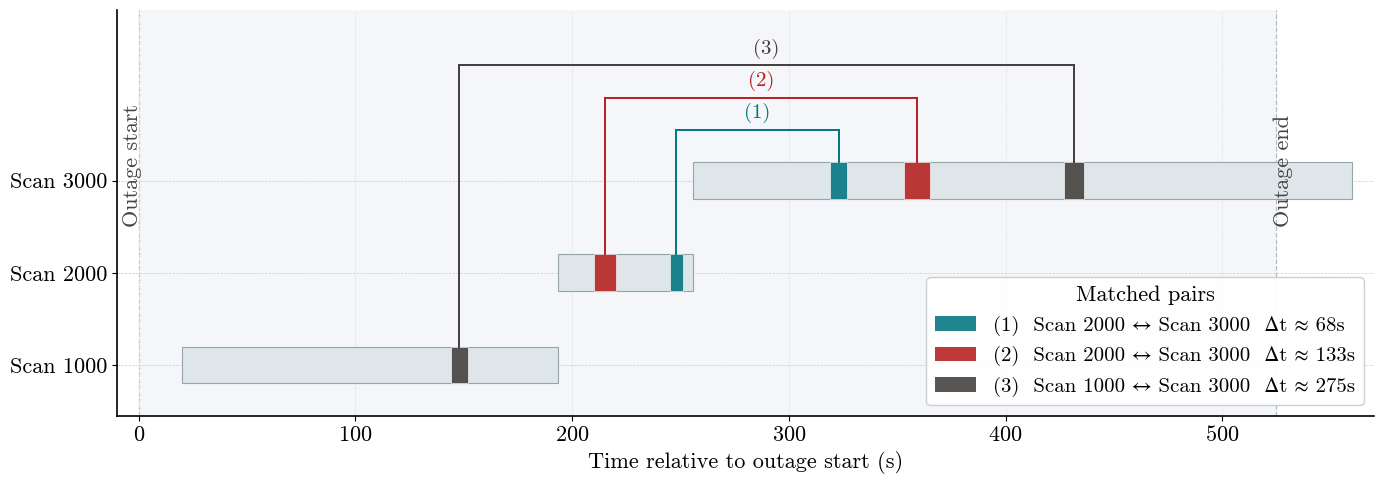

Done


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

FS = 16

fig, ax_cross = plt.subplots(figsize=(14, 5))

T_OUTAGE_START = 305120
T_OUTAGE_END   = 305645
T0 = T_OUTAGE_START
def tr(t): return t - T0

SCANLINES = {
    1000: (305140.0, 305313.5),
    2000: (305313.5, 305375.9),
    3000: (305375.9, 305680.0),
}

PAIRS_PLOT = [
    (2000, 305365, 305371, 3000, 305439, 305447),
    (2000, 305330, 305340, 3000, 305473, 305485),
    (1000, 305264, 305272, 3000, 305547, 305556),
]

COLORS_PLOT = [
    "#007480",
    "#B51F1F",
    "#413D3A",
]
BRIDGE_OFFSETS = [0.55, 0.90, 1.25]

SCAN_IDS = sorted(SCANLINES.keys())
y_map    = {sid: i for i, sid in enumerate(SCAN_IDS)}
N        = len(SCAN_IDS)

def intervals_overlap(a0, a1, b0, b1): return a0 < b1 and b0 < a1

scan_pair_windows = defaultdict(list)
for idx, pair in enumerate(PAIRS_PLOT):
    sA, tsA, teA, sB, tsB, teB = pair
    scan_pair_windows[sA].append((idx, tsA, teA, "A"))
    scan_pair_windows[sB].append((idx, tsB, teB, "B"))

segment_slot = {}
for sid, entries in scan_pair_windows.items():
    used = [False]*len(entries); groups = []
    for i in range(len(entries)):
        if used[i]: continue
        group = [i]; used[i] = True
        for j in range(i+1, len(entries)):
            if used[j]: continue
            for k in group:
                _, t0_, t1_, _ = entries[k]; _, t0j, t1j, _ = entries[j]
                if intervals_overlap(t0_, t1_, t0j, t1j):
                    group.append(j); used[j] = True; break
        groups.append(group)
    for group in groups:
        for slot, g_idx in enumerate(group):
            pidx, ts, te, role = entries[g_idx]
            segment_slot[(pidx, role)] = (slot, len(group))

def draw_segment(ax, y, ts, te, color, slot, n_slots):
    H_FULL = 0.4; h = H_FULL/n_slots
    y0 = y + H_FULL/2 - h/2 - slot*h
    ax.barh(y0, tr(te)-tr(ts), left=tr(ts), height=h,
            color=color, alpha=0.88, edgecolor="white", lw=0.5, zorder=3)

ax_cross.axvspan(tr(T_OUTAGE_START), tr(T_OUTAGE_END), color="#f5f6fa", zorder=0)
for xv in [tr(T_OUTAGE_START), tr(T_OUTAGE_END)]:
    ax_cross.axvline(xv, color="#b2bec3", lw=0.9, ls="--", zorder=1)

for sid, (ts, te) in SCANLINES.items():
    ax_cross.barh(y_map[sid], tr(te)-tr(ts), left=tr(ts), height=0.4,
                  color="#dfe6e9", edgecolor="#95a5a6", lw=0.8, zorder=2)

for idx, (pair, color) in enumerate(zip(PAIRS_PLOT, COLORS_PLOT)):
    sA, tsA, teA, sB, tsB, teB = pair
    slot_A, n_A = segment_slot.get((idx,"A"),(0,1))
    slot_B, n_B = segment_slot.get((idx,"B"),(0,1))
    draw_segment(ax_cross, y_map[sA], tsA, teA, color, slot_A, n_A)
    draw_segment(ax_cross, y_map[sB], tsB, teB, color, slot_B, n_B)
    yA = y_map[sA]; yB = y_map[sB]
    xA = tr((tsA+teA)/2); xB = tr((tsB+teB)/2)
    y_bridge = max(yA,yB) + BRIDGE_OFFSETS[idx]
    ax_cross.plot([xA,xA],[yA+0.2,y_bridge], color=color, lw=1.4, zorder=4)
    ax_cross.plot([xB,xB],[yB+0.2,y_bridge], color=color, lw=1.4, zorder=4)
    ax_cross.plot([xA,xB],[y_bridge,y_bridge], color=color, lw=1.4, zorder=4)
    ax_cross.text((xA+xB)/2, y_bridge+0.07, f"({idx+1})",
                  ha="center", va="bottom", fontsize=FS-1,
                  color=color, fontweight="bold")

ax_cross.set_yticks(list(y_map.values()))
ax_cross.set_yticklabels([f"Scan {sid}" for sid in SCAN_IDS], fontsize=FS)
ax_cross.set_xlabel("Time relative to outage start (s)", fontsize=FS)
ax_cross.tick_params(axis="both", labelsize=FS)
ax_cross.set_xlim(tr(305110), tr(305690))
ax_cross.set_ylim(-0.55, N + 0.85)
ax_cross.grid(axis="x", color="#dfe6e9", lw=0.6, zorder=0)
ax_cross.spines[["top","right"]].set_visible(False)

ax_cross.text(tr(T_OUTAGE_START)-3, N-1.5, "Outage start",
              fontsize=FS, color="#444444",
              va="bottom", ha="center", fontstyle="italic", rotation=90)
ax_cross.text(tr(T_OUTAGE_END)+3, N-1.5, "Outage end",
              fontsize=FS, color="#444444",
              va="bottom", ha="center", fontstyle="italic", rotation=90)

legend_handles = [
    mpatches.Patch(facecolor=c, alpha=0.88,
                   label=f"({i+1})  Scan {p[0]} ↔ Scan {p[3]}  "
                         f"Δt ≈ {p[4]-p[2]:.0f}s")
    for i, (p, c) in enumerate(zip(PAIRS_PLOT, COLORS_PLOT))
]
ax_cross.legend(handles=legend_handles, fontsize=FS-1, ncol=1,
                loc="lower right", framealpha=0.95,
                title="Matched pairs", title_fontsize=FS)

plt.tight_layout()
plt.savefig("/home/b085164/PDM_Romain_Defferrard/images/crossing_out1_relative_eval.png",
            bbox_inches="tight", dpi=400)
plt.show()
print("Done")

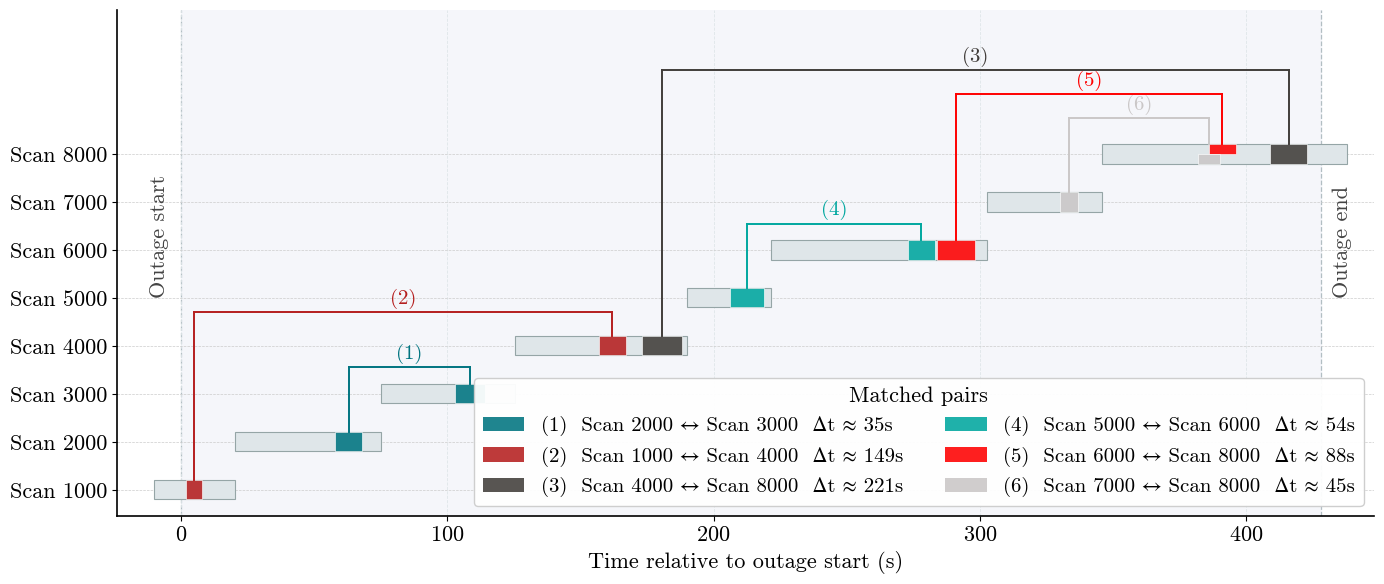

Done


In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict

FS = 16

fig, ax_cross = plt.subplots(figsize=(14, 6))

T_OUTAGE_START = 315642
T_OUTAGE_END   = 316070
T0 = T_OUTAGE_START
def tr(t): return t - T0

SCANLINES = {
    1000: (315632.0, 315662.3),
    2000: (315662.3, 315717.2),
    3000: (315717.2, 315767.4),
    4000: (315767.4, 315832.1),
    5000: (315832.1, 315863.7),
    6000: (315863.7, 315944.6),
    7000: (315944.6, 315987.8),
    8000: (315987.8, 316080.0),
}

PAIRS_PLOT = [
    (2000, 315700, 315710, 3000, 315745, 315756),
    (1000, 315644, 315650, 4000, 315799, 315809),
    (4000, 315815, 315830, 8000, 316051, 316065),
    (5000, 315848, 315861, 6000, 315915, 315925),
    (6000, 315926, 315940, 8000, 316028, 316038),
    (7000, 315972, 315979, 8000, 316024, 316032),
]

COLORS_PLOT = [
    "#007480",
    "#B51F1F",
    "#413D3A",
    "#00A79F",
    "#FF0000",
    "#CAC7C7",
]
BRIDGE_OFFSETS = [0.55, 0.70, 1.75, 0.55, 1.25, 0.75]

SCAN_IDS = sorted(SCANLINES.keys())
y_map    = {sid: i for i, sid in enumerate(SCAN_IDS)}
N        = len(SCAN_IDS)

def intervals_overlap(a0, a1, b0, b1): return a0 < b1 and b0 < a1

scan_pair_windows = defaultdict(list)
for idx, pair in enumerate(PAIRS_PLOT):
    sA, tsA, teA, sB, tsB, teB = pair
    scan_pair_windows[sA].append((idx, tsA, teA, "A"))
    scan_pair_windows[sB].append((idx, tsB, teB, "B"))

segment_slot = {}
for sid, entries in scan_pair_windows.items():
    used = [False]*len(entries); groups = []
    for i in range(len(entries)):
        if used[i]: continue
        group = [i]; used[i] = True
        for j in range(i+1, len(entries)):
            if used[j]: continue
            for k in group:
                _, t0_, t1_, _ = entries[k]; _, t0j, t1j, _ = entries[j]
                if intervals_overlap(t0_, t1_, t0j, t1j):
                    group.append(j); used[j] = True; break
        groups.append(group)
    for group in groups:
        for slot, g_idx in enumerate(group):
            pidx, ts, te, role = entries[g_idx]
            segment_slot[(pidx, role)] = (slot, len(group))

def draw_segment(ax, y, ts, te, color, slot, n_slots):
    H_FULL = 0.4; h = H_FULL/n_slots
    y0 = y + H_FULL/2 - h/2 - slot*h
    ax.barh(y0, tr(te)-tr(ts), left=tr(ts), height=h,
            color=color, alpha=0.88, edgecolor="white", lw=0.5, zorder=3)

ax_cross.axvspan(tr(T_OUTAGE_START), tr(T_OUTAGE_END), color="#f5f6fa", zorder=0)
for xv in [tr(T_OUTAGE_START), tr(T_OUTAGE_END)]:
    ax_cross.axvline(xv, color="#b2bec3", lw=0.9, ls="--", zorder=1)

for sid, (ts, te) in SCANLINES.items():
    ax_cross.barh(y_map[sid], tr(te)-tr(ts), left=tr(ts), height=0.4,
                  color="#dfe6e9", edgecolor="#95a5a6", lw=0.8, zorder=2)

for idx, (pair, color) in enumerate(zip(PAIRS_PLOT, COLORS_PLOT)):
    sA, tsA, teA, sB, tsB, teB = pair
    slot_A, n_A = segment_slot.get((idx,"A"),(0,1))
    slot_B, n_B = segment_slot.get((idx,"B"),(0,1))
    draw_segment(ax_cross, y_map[sA], tsA, teA, color, slot_A, n_A)
    draw_segment(ax_cross, y_map[sB], tsB, teB, color, slot_B, n_B)
    yA = y_map[sA]; yB = y_map[sB]
    xA = tr((tsA+teA)/2); xB = tr((tsB+teB)/2)
    y_bridge = max(yA,yB) + BRIDGE_OFFSETS[idx]
    ax_cross.plot([xA,xA],[yA+0.2,y_bridge], color=color, lw=1.4, zorder=4)
    ax_cross.plot([xB,xB],[yB+0.2,y_bridge], color=color, lw=1.4, zorder=4)
    ax_cross.plot([xA,xB],[y_bridge,y_bridge], color=color, lw=1.4, zorder=4)
    ax_cross.text((xA+xB)/2, y_bridge+0.07, f"({idx+1})",
                  ha="center", va="bottom", fontsize=FS-1,
                  color=color, fontweight="bold")

ax_cross.set_yticks(list(y_map.values()))
ax_cross.set_yticklabels([f"Scan {sid}" for sid in SCAN_IDS], fontsize=FS)
ax_cross.set_xlabel("Time relative to outage start (s)", fontsize=FS)
ax_cross.tick_params(axis="both", labelsize=FS)
ax_cross.set_xlim(tr(315618), tr(316090))
ax_cross.set_ylim(-0.55, N + 2.0)
ax_cross.grid(axis="x", color="#dfe6e9", lw=0.6, zorder=0)
ax_cross.spines[["top","right"]].set_visible(False)

ax_cross.text(tr(T_OUTAGE_START)-8, N-4, "Outage start",
              fontsize=FS, color="#444444",
              va="bottom", ha="center", fontstyle="italic", rotation=90)
ax_cross.text(tr(T_OUTAGE_END)+8, N-4, "Outage end",
              fontsize=FS, color="#444444",
              va="bottom", ha="center", fontstyle="italic", rotation=90)

legend_handles = [
    mpatches.Patch(facecolor=c, alpha=0.88,
                   label=f"({i+1})  Scan {p[0]} ↔ Scan {p[3]}  "
                         f"Δt ≈ {p[4]-p[2]:.0f}s")
    for i, (p, c) in enumerate(zip(PAIRS_PLOT, COLORS_PLOT))
]
ax_cross.legend(handles=legend_handles, fontsize=FS-1, ncol=2,
                loc="lower right", framealpha=0.95,
                title="Matched pairs", title_fontsize=FS)

plt.tight_layout()
plt.savefig("/home/b085164/PDM_Romain_Defferrard/images/crossing_ECCR_relative_eval.png",
            bbox_inches="tight", dpi=400)
plt.show()
print("Done")